In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.formula.api as smf
import statsmodels.stats as sms
import statsmodels.api as sm

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
base = pio.templates["simple_white"]
custom_template = base.layout.template

custom_template.layout.update(
    margin=dict(l=50, r=50, t=20, b=50),
    xaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    yaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    colorscale=dict(
        sequential=px.colors.sequential.Inferno,
        diverging=px.colors.diverging.curl_r
    ),
    colorway=px.colors.qualitative.T10
)

pio.templates["tight"] = custom_template
pio.templates.default = "tight"

In [3]:
kc = pd.read_csv('kc_house_data.csv')

In [4]:
kc['date'] = pd.to_datetime(kc.date)

sqft_to_sqmeters = 0.09290303997

kc = kc.astype({'sqft_living': float, 'sqft_lot': float, 
                'sqft_above': float, 'sqft_basement': float,
                'sqft_living15': float, 'sqft_lot15': float,
                'yr_renovated': float, 'yr_built': float,
                'bedrooms': float, 'waterfront': float,
                'view': float, 'condition': float, 'grade': float})

kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] =\
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] * sqft_to_sqmeters

kc.columns = ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqm_living',
       'sqm_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqm_living15', 'sqm_lot15']

kc = kc.loc[:, ['id', 'date', 'price', 
            'floors', 'bedrooms', 'bathrooms', 
            'yr_built', 'yr_renovated',
            'waterfront', 'view', 'condition', 'grade', 
            'sqm_living', 'sqm_lot', 
            'sqm_above', 'sqm_basement',
            'sqm_living15', 'sqm_lot15',
            'lat', 'long']]

kc.loc[kc.sqm_basement == 0, 'sqm_basement'] = np.nan
kc.loc[kc.yr_renovated == 0, 'yr_renovated'] = np.nan

In [5]:
kc_log = kc.copy()
kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']] = \
np.log10(kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']])

In [6]:
kc_log.yr_renovated = kc_log.yr_renovated.fillna(kc_log.yr_built)
kc_log.loc[:,'sqm_basement'] = kc_log.loc[:,'sqm_basement'].fillna(0)
kc.yr_renovated = kc.yr_renovated.fillna(kc.yr_built)
kc.loc[:,'sqm_basement'] = kc.loc[:,'sqm_basement'].fillna(0)

In [7]:
kc_z=kc.copy()
for col in kc_z.drop(columns=['id', 'date']).columns:
    kc_z.loc[:,col] = st.zscore(kc_z.loc[:,col])

In [166]:
X = kc.drop(columns=['id', 'date', 'price', 'sqm_above', 'lat', 'long'])

# X = kc.drop(columns=['id', 'date', 'price', 'yr_renovated',
#                                 'sqm_above', 'sqm_basement',
#                                 'sqm_living15', 'sqm_lot15',
#                                 'lat', 'long'])

y = kc.price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
"Linear Regression": LinearRegression(),
"Ridge": Ridge(alpha=2000, random_state=42),
"Lasso": Lasso(alpha=22000, random_state=42, max_iter=10000),
"ElasticNet": ElasticNet(l1_ratio=0.9999999, alpha=22000, random_state=42)
}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)

    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    results = pd.DataFrame(data = 0.0, index=['r2', 'mse', 'rmse', 'mae'], columns=['test', 'train', 'ratio'])
    results.test=[r2, mse, rmse, mae]
    results.train=[r2_train, mse_train, rmse_train, mae_train]
    results.ratio=[100*r2_train/r2, 100*mse_train/mse, 100*rmse_train/rmse, 100*mae_train/mae]

    print('======== ', name, ' ========\n')
    print(results, '\n')

    print('Coefficients  (abs):')
    print('Intercept    ', round(model.intercept_, 6))
    print(pd.Series(data=np.abs(model.coef_), index=X.columns).sort_values(ascending=False), '\n')

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, scoring='r2', cv=cv)
    print(f"CV R² mean: {cv_scores.mean():.4f} | std: {cv_scores.std():.4f}", '\n')

# Evaluate all models
for name, model in models.items():
    evaluate_model(name, model, X_train_scaled, X_test_scaled, y_train, y_test)

========  Linear Regression  ========

              test         train      ratio
r2    6.540027e-01  6.533348e-01  99.897869
mse   5.230673e+10  4.529133e+10  86.587958
rmse  2.287066e+05  2.128176e+05  93.052651
mae   1.432000e+05  1.386572e+05  96.827623 

Coefficients  (abs):
Intercept     537768.047947
sqm_living      144293.047259
grade           138176.688528
yr_built        112821.211190
waterfront       47058.355906
bathrooms        37949.845112
bedrooms         36042.176675
view             33432.949199
sqm_living15     17248.502431
floors           15303.058893
sqm_lot15        12622.021423
condition        10873.369242
yr_renovated      5387.443215
sqm_basement      2907.644655
sqm_lot           1759.950811
dtype: float64 

CV R² mean: 0.6495 | std: 0.0122 

========  Ridge  ========

              test         train       ratio
r2    6.459203e-01  6.464387e-01  100.080254
mse   5.352860e+10  4.619229e+10   86.294602
rmse  2.313625e+05  2.149239e+05   92.894888
mae   1.416

In [54]:
np.logspace(start=1, stop=7, num=25, base=10)

array([1.00000000e+01, 1.77827941e+01, 3.16227766e+01, 5.62341325e+01,
       1.00000000e+02, 1.77827941e+02, 3.16227766e+02, 5.62341325e+02,
       1.00000000e+03, 1.77827941e+03, 3.16227766e+03, 5.62341325e+03,
       1.00000000e+04, 1.77827941e+04, 3.16227766e+04, 5.62341325e+04,
       1.00000000e+05, 1.77827941e+05, 3.16227766e+05, 5.62341325e+05,
       1.00000000e+06, 1.77827941e+06, 3.16227766e+06, 5.62341325e+06,
       1.00000000e+07])

In [47]:
np.logspace(start=5.2, stop=5.3, num=20, base=2)

array([36.75834736, 36.89269197, 37.02752759, 37.16285601, 37.29867902,
       37.43499845, 37.57181609, 37.70913377, 37.84695333, 37.98527659,
       38.12410539, 38.26344158, 38.40328703, 38.54364358, 38.6845131 ,
       38.82589748, 38.96779859, 39.11021832, 39.25315856, 39.39662123])

In [58]:
coef_df = pd.DataFrame(data=0.0, index=range(100), columns=['a', 'r2', 'intercept'] + [*X_train.columns.values])
i=0
for a in np.logspace(start=1, stop=8, num=100, base=10):
    ridge_test = Ridge(alpha=a, random_state=42)
    ridge_test.fit(X_train_scaled, y_train)
    coef_df.loc[i, 'a'] = a
    coef_df.loc[i, 'r2'] = ridge_test.score(X_train_scaled, y_train)
    coef_df.loc[i, 'intercept'] = ridge_test.intercept_
    coef_df.loc[i, 'floors':] = ridge_test.coef_
    i+=1

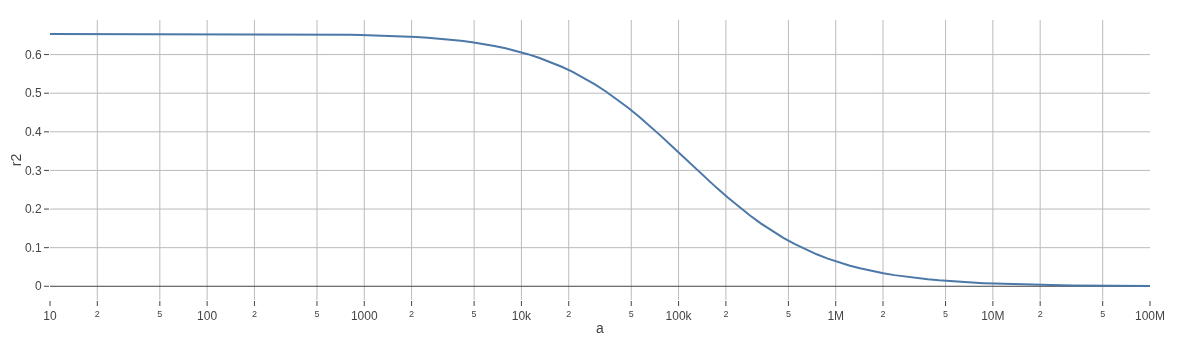

In [59]:
px.line(coef_df, x='a', y='r2', log_x=True, width = 1200).show(renderer='png', width = 1200, height=350)

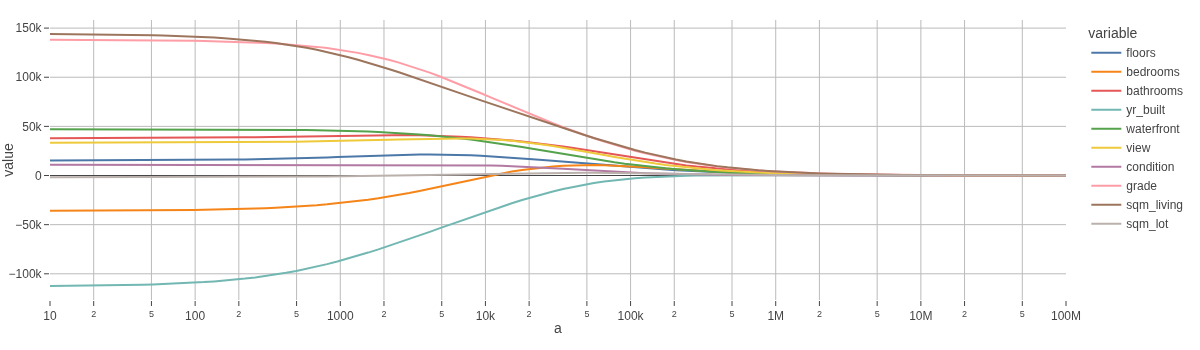

In [60]:
px.line(coef_df, x='a', y=['floors', 'bedrooms', 'bathrooms', 'yr_built', 'waterfront', 'view',
       'condition', 'grade', 'sqm_living', 'sqm_lot'], log_x=True).show(renderer='png', width = 1200, height=350)

In [147]:
coef_df = pd.DataFrame(data=0.0, index=range(100), columns=['a', 'r2', 'intercept'] + [*X_train.columns.values])
i=0
for a in np.logspace(start=1, stop=8, num=100, base=10):
    lasso_test = Lasso(alpha=a, random_state=42, max_iter=10000)
    lasso_test.fit(X_train_scaled, y_train)
    coef_df.loc[i, 'a'] = a
    coef_df.loc[i, 'r2'] = lasso_test.score(X_train_scaled, y_train)
    coef_df.loc[i, 'intercept'] = lasso_test.intercept_
    coef_df.loc[i, 'floors':] = lasso_test.coef_
    i+=1
coef_df

,a,r2,intercept,floors,bedrooms,bathrooms,yr_built,yr_renovated,waterfront,view,condition,grade,sqm_living,sqm_lot,sqm_basement,sqm_living15,sqm_lot15
0,1.000000e+01,0.653335,537768.047947,15289.272170,-36016.174431,37945.491834,-112705.716879,5273.913837,47052.741259,33435.892525,10855.437935,138179.122494,144288.662647,-1753.406434,2898.694445,17232.799459,-12613.967194
1,1.176812e+01,0.653335,537768.047947,15286.746660,-36011.519565,37944.905649,-112685.326857,5253.818788,47051.752332,33436.423568,10852.260997,138179.853174,144287.529977,-1752.270439,2897.120184,17229.984947,-12612.507158
2,1.384886e+01,0.653335,537768.047947,15283.973934,-36006.103555,37944.003905,-112661.633327,5230.528353,47050.579983,33437.030573,10848.536426,138180.157652,144286.591151,-1750.897902,2895.280485,17226.850205,-12610.834141
3,1.629751e+01,0.653335,537768.047947,15280.507378,-35999.642543,37943.217915,-112633.454455,5202.764184,47049.209686,33437.770500,10844.138066,138181.116808,144284.953415,-1749.322301,2893.117788,17223.006207,-12608.808297
4,1.917910e+01,0.653335,537768.047947,15276.433372,-35992.006802,37942.366887,-112600.292326,5170.092449,47047.597818,33438.652134,10838.961069,138182.275188,144282.857076,-1747.471343,2890.595777,17218.522987,-12606.410615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5.214008e+07,0.000000,537768.047947,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
96,6.135907e+07,0.000000,537768.047947,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
97,7.220809e+07,0.000000,537768.047947,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
98,8.497534e+07,0.000000,537768.047947,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


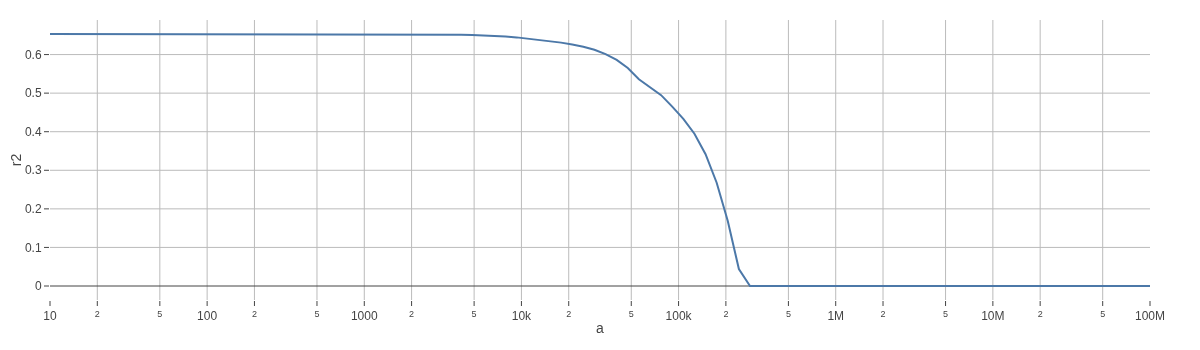

In [148]:
px.line(coef_df, x='a', y='r2', log_x=True, width = 1200).show(renderer='png', width = 1200, height=350)

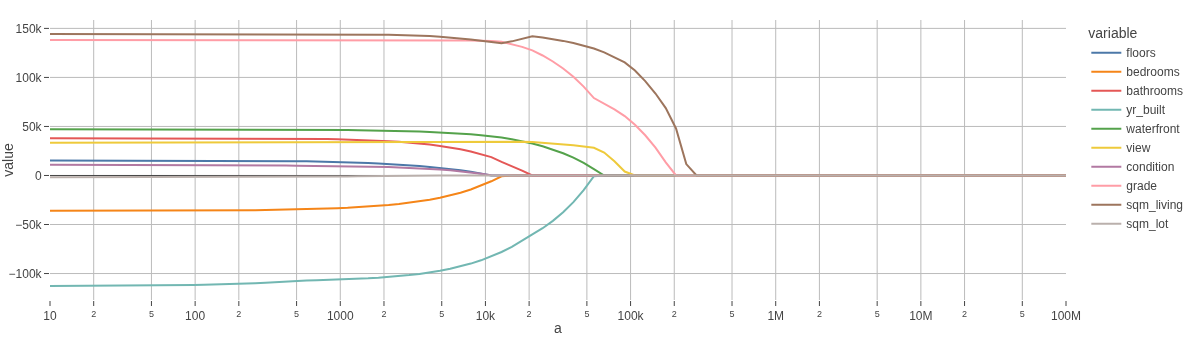

In [150]:
px.line(coef_df, x='a', y=['floors', 'bedrooms', 'bathrooms', 'yr_built', 'waterfront', 'view',
       'condition', 'grade', 'sqm_living', 'sqm_lot'], log_x=True).show(renderer='png', width = 1200, height=350)

In [144]:
coef_df = pd.DataFrame(data=0.0, index=range(100), columns=['a', 'r2', 'intercept'] + [*X_train.columns.values])
i=0
for a in np.logspace(start=1, stop=8, num=100, base=10):
    elastic_test = ElasticNet(alpha=a, l1_ratio=0.9999999,random_state=42, max_iter=10000)
    elastic_test.fit(X_train_scaled, y_train)
    coef_df.loc[i, 'a'] = a
    coef_df.loc[i, 'r2'] = elastic_test.score(X_train_scaled, y_train)
    coef_df.loc[i, 'intercept'] = elastic_test.intercept_
    coef_df.loc[i, 'floors':] = elastic_test.coef_
    i+=1

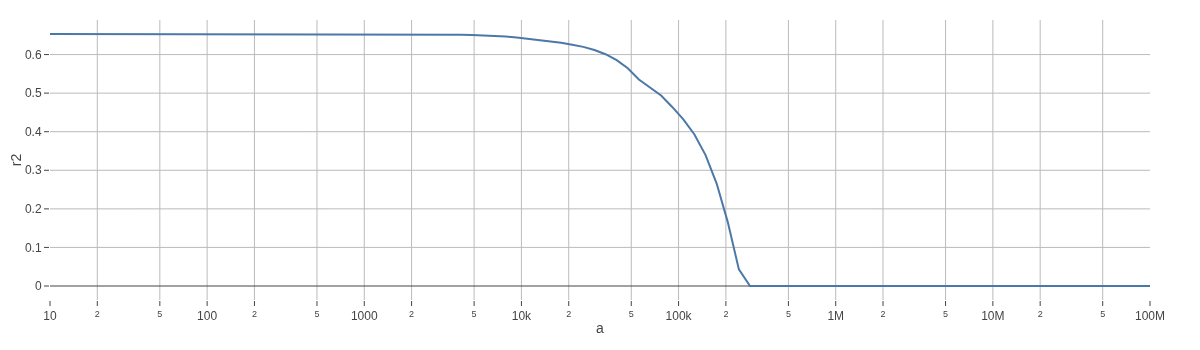

In [145]:
px.line(coef_df, x='a', y='r2', log_x=True, width = 1200).show(renderer='png', width = 1200, height=350)

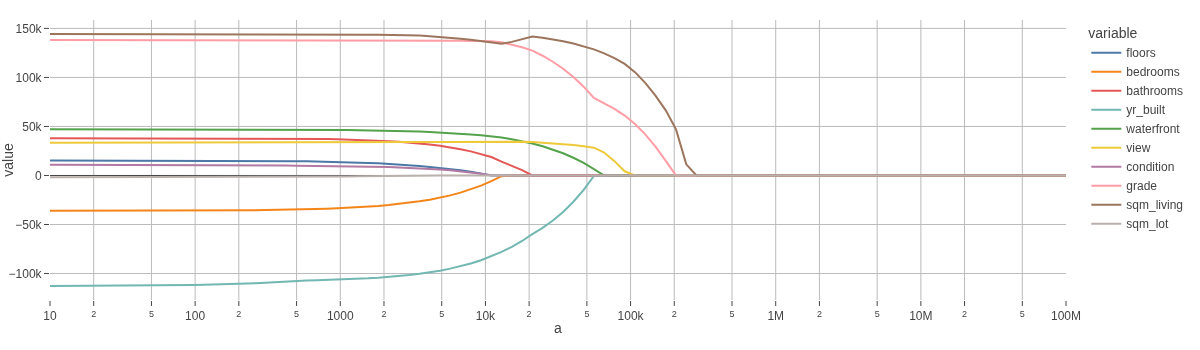

In [146]:
px.line(coef_df, x='a', y=['floors', 'bedrooms', 'bathrooms', 'yr_built', 'waterfront', 'view',
       'condition', 'grade', 'sqm_living', 'sqm_lot'], log_x=True).show(renderer='png', width = 1200, height=350)